In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")

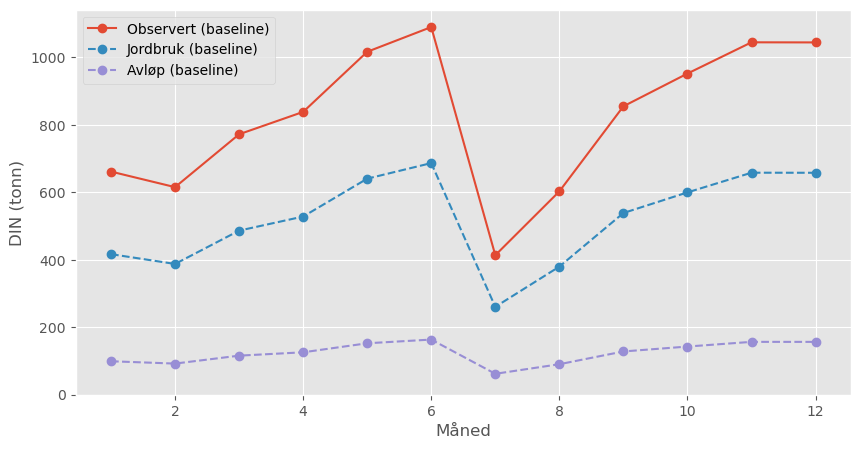

In [2]:
csv_path = r"../data/daily_river_fluxes_2017-2019_Baseline_Glomma.csv"
df = pd.read_csv(csv_path)

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df["month"] = df["date"].dt.month
df = df[["month", "DIN"]].groupby("month").sum() / 3000
df.columns = ["Observert (baseline)"]

df["Jordbruk (baseline)"] = 0.63 * df["Observert (baseline)"]
df["Avløp (baseline)"] = 0.15 * df["Observert (baseline)"]

ax = df.plot(
    figsize=(10, 5),
    marker="o",
    style={
        "Observert (baseline)": "-",
        "Jordbruk (baseline)": "--",
        "Avløp (baseline)": "--",
    },
)
ax.set_ylim(0)
ax.set_xlabel("Måned")
ax.set_ylabel("DIN (tonn)")

plt.savefig(
    r"../plots/glomma_monthly_source_apportionment.png", dpi=200, bbox_inches="tight"
)

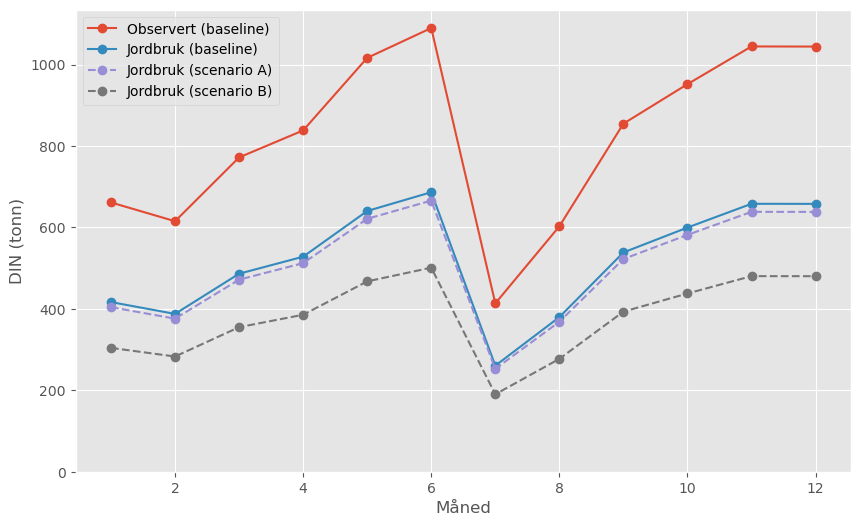

In [3]:
del df["Avløp (baseline)"]

# 3% agri reduction under ScA
df["Jordbruk (scenario A)"] = 0.97 * df["Jordbruk (baseline)"]

# 27% agri reduction under ScB
df["Jordbruk (scenario B)"] = 0.73 * df["Jordbruk (baseline)"]

ax = df.plot(
    figsize=(10, 6),
    marker="o",
    style={
        "Observert (baseline)": "-",
        "Jordbruk (baseline)": "-",
        "Jordbruk (scenario A)": "--",
        "Jordbruk (scenario B)": "--",
    },
)
ax.set_ylim(0)
ax.set_xlabel("Måned")
ax.set_ylabel("DIN (tonn)");

plt.savefig(
    r"../plots/glomma_monthly_agri_scenarios.png", dpi=200, bbox_inches="tight"
)